INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Laptop GPU, compute capability 8.6


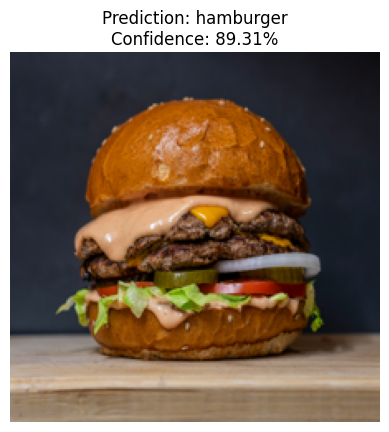

Top 3 predictions:
  1. hamburger: 89.31%
  2. pulled_pork_sandwich: 9.31%
  3. club_sandwich: 0.28%


In [ ]:
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load model
model = tf.keras.models.load_model("../models/food_classifier.keras")

# Class names (save these during training)
class_names = ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque',
               'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_soup', 'mussels', 'nachos', 'omelette', 'onion_rings', 'oysters', 'pad_thai', 'paella', 'pancakes', 'panna_cotta', 'peking_duck', 'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib', 'pulled_pork_sandwich', 'ramen', 'ravioli', 'red_velvet_cake', 'risotto', 'samosa', 'sashimi', 'scallops', 'seaweed_salad', 'shrimp_and_grits', 'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake', 
               'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles']  #

# Predict on a new image
def predict_food(image_path):
    img = Image.open(image_path).resize((224, 224))
    img_array = np.array(img)
    img_normalized = (img_array / 127.5) - 1.0 ## just to be the value between -1 and 1 for our EfficientnetV2b0 requirement 
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    pred = model.predict(img_batch, verbose=0)
    top_3_idx = pred[0].argsort()[-3:][::-1]
    
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[top_3_idx[0]]}\n"
              f"Confidence: {pred[0][top_3_idx[0]]:.2%}")
    plt.axis('off')
    plt.show()
    
    print("Top 3 predictions:")
    for i, idx in enumerate(top_3_idx):
        print(f"  {i+1}. {class_names[idx]}: {pred[0][idx]:.2%}")

# Test
predict_food("extra_images\Burger.jpg") ## copy all the path and past it here or your cutom path to test the model on your own images